In [1]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import os
import time

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

# Check device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Using Apple M3 GPU (Metal)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✓ Using NVIDIA GPU")
else:
    device = torch.device("cpu")
    print(" Using CPU")

print(f"Device: {device}")



 Using CPU
Device: cpu


In [2]:


# Load splits
train_data = pd.read_pickle('final_dataset/train_data_final.pkl')
val_data_masked = pd.read_pickle('final_dataset/val_data_masked.pkl')
test_data_masked = pd.read_pickle('final_dataset/test_data_masked.pkl')

# Load ground truth and masks
val_ground_truth = pd.read_pickle('final_dataset/val_ground_truth.pkl')
test_ground_truth = pd.read_pickle('final_dataset/test_ground_truth.pkl')
val_mask_indicator = pd.read_pickle('final_dataset/val_mask_indicator.pkl')
test_mask_indicator = pd.read_pickle('final_dataset/test_mask_indicator.pkl')

print(f"\n✓ Loaded splits:")
print(f"  • Train: {train_data.shape}")
print(f"  • Val: {val_data_masked.shape}")
print(f"  • Test: {test_data_masked.shape}")

# Get features to impute (from ground truth columns)
features_to_impute = val_ground_truth.columns.tolist()

print(f"  • Features to impute: {len(features_to_impute)}")


✓ Loaded splits:
  • Train: (143459, 97)
  • Val: (30741, 97)
  • Test: (30742, 97)
  • Features to impute: 46


In [3]:
def clip_outliers_per_feature(data, features, lower_pct=0.5, upper_pct=99.5, 
                               reference_data=None):
    """
    Clip outliers per feature based on percentiles.
    
    Args:
        data: DataFrame to clip
        features: List of features to clip
        lower_pct: Lower percentile
        upper_pct: Upper percentile
        reference_data: If provided, use this data's percentiles (for val/test)
    """
    data_clipped = data.copy()
    clipping_bounds = {}
    
    for feat in features:
        if feat not in data.columns:
            continue
        
        # Determine which data to use for percentiles
        if reference_data is not None:
            ref_col = reference_data[feat].dropna()
        else:
            ref_col = data[feat].dropna()
        
        if len(ref_col) == 0:
            continue
        
        # Calculate bounds
        lower_bound = np.percentile(ref_col, lower_pct)
        upper_bound = np.percentile(ref_col, upper_pct)
        
        clipping_bounds[feat] = (lower_bound, upper_bound)
        
        # Clip values (only non-NaN)
        mask = data_clipped[feat].notna()
        data_clipped.loc[mask, feat] = data_clipped.loc[mask, feat].clip(
            lower=lower_bound, 
            upper=upper_bound
        )
    
    return data_clipped, clipping_bounds

print("\n Clipping training data (fit bounds)...")
train_clipped, clipping_bounds = clip_outliers_per_feature(
    train_data, 
    features_to_impute
)

print("✓ Training data clipped")

# Show some clipping examples
print(f"\n Clipping examples (first 5 features):")
for i, feat in enumerate(list(clipping_bounds.keys())[:5]):
    lower, upper = clipping_bounds[feat]
    original_min = train_data[feat].min()
    original_max = train_data[feat].max()
    print(f"  • {feat[:40]:40s}: [{original_min:>10.2e}, {original_max:>10.2e}] → [{lower:>10.2e}, {upper:>10.2e}]")

# Clip val and test using SAME bounds (from training)
print("\n🔧 Clipping val/test data (using training bounds)...")
val_clipped, _ = clip_outliers_per_feature(
    val_data_masked, 
    features_to_impute,
    reference_data=train_data
)

test_clipped, _ = clip_outliers_per_feature(
    test_data_masked, 
    features_to_impute,
    reference_data=train_data
)

print("✓ Val/test data clipped")

# CRITICAL: Also clip ground truth
print("\n🔧 Clipping ground truth (same bounds)...")
val_gt_clipped, _ = clip_outliers_per_feature(
    val_ground_truth,
    features_to_impute,
    reference_data=train_data
)

test_gt_clipped, _ = clip_outliers_per_feature(
    test_ground_truth,
    features_to_impute,
    reference_data=train_data
)

print("✓ Ground truth clipped")


 Clipping training data (fit bounds)...
✓ Training data clipped

 Clipping examples (first 5 features):
  • ping_ms                                 : [  2.83e+00,   1.14e+01] → [  3.04e+00,   8.65e+00]
  • datarate                                : [  6.75e+00,   1.93e+01] → [  1.29e+01,   1.88e+01]
  • jitter                                  : [  1.60e-05,   1.01e+08] → [  4.70e-05,   3.86e-02]
  • Latitude                                : [  5.25e+01,   5.25e+01] → [  5.25e+01,   5.25e+01]
  • Longitude                               : [  1.32e+01,   1.34e+01] → [  1.33e+01,   1.34e+01]

🔧 Clipping val/test data (using training bounds)...
✓ Val/test data clipped

🔧 Clipping ground truth (same bounds)...
✓ Ground truth clipped


In [4]:

scaler = StandardScaler()

# Extract values for features to impute
train_values = train_clipped[features_to_impute].values
val_values = val_clipped[features_to_impute].values
test_values = test_clipped[features_to_impute].values

# Fit scaler on training data
scaler.fit(train_values)

# Transform all datasets
train_scaled = scaler.transform(train_values)
val_scaled = scaler.transform(val_values)
test_scaled = scaler.transform(test_values)

print(f"\n✓ Scaled all datasets")

# Verify scale quality
print(f"\nScaled data statistics:")
print(f"  • Train mean: {np.nanmean(train_scaled):.4f}")
print(f"  • Train std:  {np.nanstd(train_scaled):.4f}")
print(f"  • Train min:  {np.nanmin(train_scaled):.4f}")
print(f"  • Train max:  {np.nanmax(train_scaled):.4f}")


✓ Scaled all datasets

Scaled data statistics:
  • Train mean: 0.0000
  • Train std:  1.0000
  • Train min:  -3.9694
  • Train max:  8.8233


In [5]:

# Get ALL column names
all_columns = train_data.columns.tolist()

# Separate features
continuous_features = features_to_impute  # 49 features (what we impute)
context_features = [col for col in all_columns if col not in continuous_features]  # 51 features
context_features.remove('timestamp')
context_features.remove('ts_gps')

print(f"\n Feature breakdown:")
print(f"  • Continuous (to impute): {len(continuous_features)}")
print(f"  • Context (indicators, temporal, one-hot): {len(context_features)}")
print(f"  • Total input features: {len(all_columns)}")

print(f"\n Context features:")
for col in context_features:
    print(f"  • {col}")



 Feature breakdown:
  • Continuous (to impute): 46
  • Context (indicators, temporal, one-hot): 49
  • Total input features: 97

 Context features:
  • ping_ms_missing
  • datarate_missing
  • jitter_missing
  • Pos in Ref Round_missing
  • PCell_Cell_ID_missing
  • PCell_TAC_missing
  • PCell_Cell_Identity_missing
  • PCell_Uplink_bandwidth_MHz_missing
  • PCell_Downlink_bandwidth_MHz_missing
  • PCell_Uplink_frequency_missing
  • PCell_Downlink_frequency_missing
  • PCell_Band_Indicator_missing
  • PCell_Uplink_Num_RBs_missing
  • PCell_Uplink_Tx_Power_(dBm)_missing
  • PCell_Uplink_TB_Size_missing
  • PCell_Downlink_Average_MCS_missing
  • PCell_Downlink_Num_RBs_missing
  • PCell_Downlink_TB_Size_missing
  • PCell_RSRP_max_missing
  • PCell_RSSI_max_missing
  • PCell_RSRQ_max_missing
  • PCell_SNR_1_missing
  • PCell_SNR_2_missing
  • PCell_freq_MHz_missing
  • PCell_E-ARFCN_missing
  • pcell_high_missing
  • device_pc1
  • device_pc2
  • device_pc3
  • device_pc4
  • area_Avenue
 

In [6]:


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import time

# Seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🔧 Device: {device}")


🔧 Device: cpu


In [7]:

print(f"\n✓ Using existing preprocessed data:")
print(f"  • Train: {train_scaled.shape}")
print(f"  • Val: {val_scaled.shape}")
print(f"  • Test: {test_scaled.shape}")


✓ Using existing preprocessed data:
  • Train: (143459, 46)
  • Val: (30741, 46)
  • Test: (30742, 46)


In [8]:

class SimpleDenoisingDataset(Dataset):
    """Simple dataset - 49 features in, 49 features out"""
    def __init__(self, data, noise_ratio=0.2, training=True):
        self.data = data
        self.noise_ratio = noise_ratio
        self.training = training
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data[idx].copy()
        
        # Mask: 1=observed, 0=missing
        mask_observed = ~np.isnan(row)
        
        # Fill NaN with 0
        row_filled = np.nan_to_num(row, nan=0.0)
        
        # Add noise (only for training)
        if self.training and mask_observed.sum() > 0:
            noisy_row = row_filled.copy()
            observed_indices = np.where(mask_observed)[0]
            n_to_mask = max(1, int(len(observed_indices) * self.noise_ratio))
            
            if n_to_mask < len(observed_indices):
                mask_indices = np.random.choice(
                    observed_indices,
                    size=n_to_mask,
                    replace=False
                )
                noisy_row[mask_indices] = 0.0
            
            return (torch.FloatTensor(noisy_row),
                    torch.FloatTensor(row_filled),
                    torch.FloatTensor(mask_observed.astype(np.float32)))
        
        # No noise for val/test
        return (torch.FloatTensor(row_filled),
                torch.FloatTensor(row_filled),
                torch.FloatTensor(mask_observed.astype(np.float32)))

# Create datasets
NOISE_RATIO = 0.2
BATCH_SIZE = 512

train_dataset = SimpleDenoisingDataset(train_scaled, noise_ratio=NOISE_RATIO, training=True)
val_dataset = SimpleDenoisingDataset(val_scaled, noise_ratio=0.0, training=False)
test_dataset = SimpleDenoisingDataset(test_scaled, noise_ratio=0.0, training=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✓ Datasets created:")
print(f"  • Train: {len(train_dataset):,} samples (20% noise)")
print(f"  • Val: {len(val_dataset):,} samples")
print(f"  • Test: {len(test_dataset):,} samples")
print(f"  • Batch size: {BATCH_SIZE}")


✓ Datasets created:
  • Train: 143,459 samples (20% noise)
  • Val: 30,741 samples
  • Test: 30,742 samples
  • Batch size: 512


In [9]:

class SimpleDenoisingAutoencoder(nn.Module):
    """Simple autoencoder: 46 → 128 → 64 → 32 → 64 → 128 → 46"""
    def __init__(self, input_dim, hidden_dims=[128, 64, 32]):
        super(SimpleDenoisingAutoencoder, self).__init__()
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_dim = hidden_dim
        
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Decoder
        decoder_layers = []
        reversed_dims = list(reversed(hidden_dims[:-1])) + [input_dim]
        
        for i, hidden_dim in enumerate(reversed_dims):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            
            if i < len(reversed_dims) - 1:
                decoder_layers.extend([
                    nn.ReLU(),
                    nn.Dropout(0.2)
                ])
            
            prev_dim = hidden_dim
        
        self.decoder = nn.Sequential(*decoder_layers)
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

INPUT_DIM = 46
HIDDEN_DIMS = [128, 64, 32]

model = SimpleDenoisingAutoencoder(INPUT_DIM, HIDDEN_DIMS).to(device)

print(f"\n✓ Model created:")
print(f"  • Architecture: {INPUT_DIM} → {' → '.join(map(str, HIDDEN_DIMS))} → {' → '.join(map(str, reversed(HIDDEN_DIMS[:-1])))} → {INPUT_DIM}")
print(f"  • Parameters: {sum(p.numel() for p in model.parameters()):,}")


✓ Model created:
  • Architecture: 46 → 128 → 64 → 32 → 64 → 128 → 46
  • Parameters: 32,718


In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

NUM_EPOCHS = 40
EARLY_STOP_PATIENCE = 10

print(f"\n⚙️  Configuration:")
print(f"  • Epochs: {NUM_EPOCHS}")
print(f"  • Learning rate: 0.001")
print(f"  • Optimizer: Adam")
print(f"  • Early stopping: {EARLY_STOP_PATIENCE}")


⚙️  Configuration:
  • Epochs: 40
  • Learning rate: 0.001
  • Optimizer: Adam
  • Early stopping: 10


In [11]:

history = {'train_loss': [], 'val_loss': [], 'epoch_times': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\n🚀 Starting training...")
print(f"{'Epoch':<8s} {'Train Loss':<15s} {'Val Loss':<15s} {'Time':<10s} {'Status'}")
print("─"*70)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    # Training
    model.train()
    train_losses = []
    
    for input_batch, target_batch, mask_batch in train_loader:
        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)
        mask_batch = mask_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(input_batch)
        
        # Loss only on observed values
        loss = criterion(outputs * mask_batch, target_batch * mask_batch)
        
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
    
    avg_train_loss = np.mean(train_losses)
    
    # Validation
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for input_batch, target_batch, mask_batch in val_loader:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            mask_batch = mask_batch.to(device)
            
            outputs = model(input_batch)
            loss = criterion(outputs * mask_batch, target_batch * mask_batch)
            
            val_losses.append(loss.item())
    
    avg_val_loss = np.mean(val_losses)
    
    # Record
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['epoch_times'].append(epoch_time)
    
    scheduler.step(avg_val_loss)
    
    # Early stopping
    status = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        status = "✓ Best"
    else:
        patience_counter += 1
        status = f"({patience_counter}/{EARLY_STOP_PATIENCE})"
    
    print(f"{epoch+1:<8d} {avg_train_loss:<15.6f} {avg_val_loss:<15.6f} {epoch_time:<10.2f}s {status}")
    
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⚠️  Early stopping at epoch {epoch+1}")
        break

# Restore best
model.load_state_dict(best_model_state)

print(f"\n✓ Training complete!")
print(f"  • Epochs: {len(history['train_loss'])}")
print(f"  • Best val loss: {best_val_loss:.6f}")
print(f"  • Total time: {sum(history['epoch_times']):.1f}s")



🚀 Starting training...
Epoch    Train Loss      Val Loss        Time       Status
──────────────────────────────────────────────────────────────────────
1        0.545726        0.361151        22.46     s ✓ Best
2        0.391192        0.316421        22.41     s ✓ Best
3        0.354824        0.300579        24.12     s ✓ Best
4        0.332726        0.293866        23.27     s ✓ Best
5        0.318297        0.288334        22.00     s ✓ Best
6        0.307034        0.278277        25.07     s ✓ Best
7        0.297792        0.264665        22.47     s ✓ Best
8        0.290189        0.255492        25.30     s ✓ Best
9        0.283165        0.249267        22.53     s ✓ Best
10       0.276768        0.241644        21.42     s ✓ Best
11       0.271540        0.234373        25.06     s ✓ Best
12       0.267345        0.230750        22.37     s ✓ Best
13       0.262499        0.225636        24.78     s ✓ Best
14       0.259143        0.221179        25.42     s ✓ Best
15    

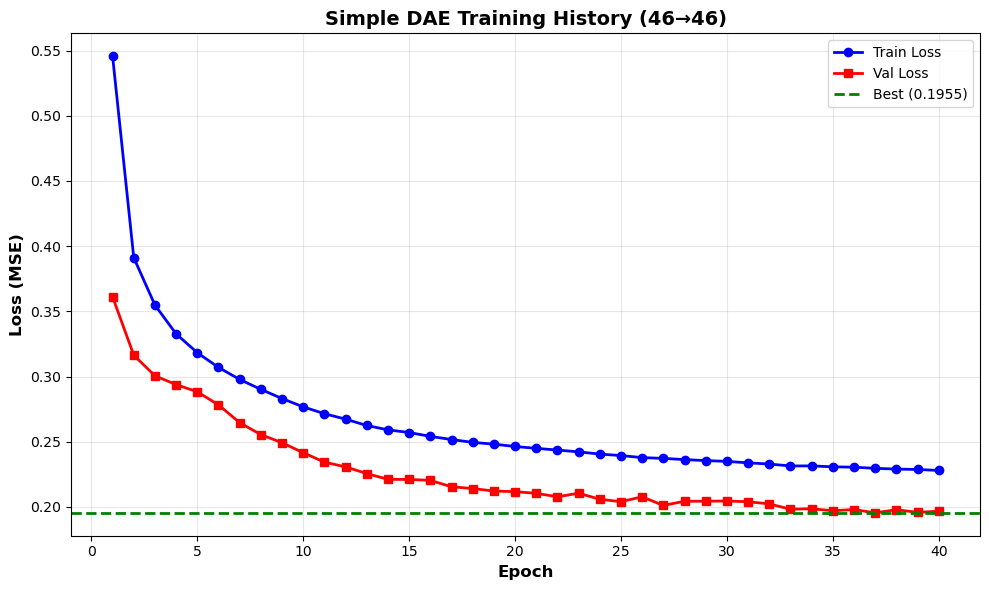


✅ SIMPLE DAE TRAINING COMPLETE

📊 RESULTS:
  • Best validation loss: 0.195470
  • Epochs: 40
  • Total time: 902.6s

🎯 NEXT: Evaluate on test set!



In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

epochs = range(1, len(history['train_loss']) + 1)

ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2, marker='o')
ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2, marker='s')
ax.axhline(y=best_val_loss, color='g', linestyle='--', linewidth=2, label=f'Best ({best_val_loss:.4f})')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
ax.set_title('Simple DAE Training History (46→46)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

print("\n" + "="*80)
print("✅ SIMPLE DAE TRAINING COMPLETE")
print("="*80)

print(f"""
📊 RESULTS:
  • Best validation loss: {best_val_loss:.6f}
  • Epochs: {len(history['train_loss'])}
  • Total time: {sum(history['epoch_times']):.1f}s

🎯 NEXT: Evaluate on test set!
""")

print("="*80)

In [13]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

model.eval()
all_predictions = []

print("\n🔮 Generating predictions on test set...")

with torch.no_grad():
    for input_batch, _, _ in test_loader:
        input_batch = input_batch.to(device)
        outputs = model(input_batch)
        all_predictions.append(outputs.cpu().numpy())

predictions_scaled = np.vstack(all_predictions)

print(f"✓ Predictions generated: {predictions_scaled.shape}")
print(f"  • In scaled space (mean≈0, std≈1)")


🔮 Generating predictions on test set...
✓ Predictions generated: (30742, 46)
  • In scaled space (mean≈0, std≈1)


In [14]:

# Inverse transform predictions
predictions_original = scaler.inverse_transform(predictions_scaled)

print(f"✓ Predictions transformed to original (clipped) scale")
print(f"  • Shape: {predictions_original.shape}")
print(f"  • Range: [{predictions_original.min():.2f}, {predictions_original.max():.2f}]")

# Create DataFrame with predictions
test_imputed = test_data_masked.copy()
test_imputed[continuous_features] = predictions_original

print(f"✓ Created imputed test dataframe")

✓ Predictions transformed to original (clipped) scale
  • Shape: (30742, 46)
  • Range: [-136.08, 21162.44]
✓ Created imputed test dataframe


In [15]:

results = []
all_errors_sq = []
all_errors_abs = []

for col in continuous_features:
    # Get mask: which positions were artificially masked?
    mask = test_mask_indicator[col]
    
    if mask.sum() == 0:
        continue  # No masked values for this feature
    
    # Get ground truth at masked positions (CLIPPED!)
    true_vals = test_gt_clipped.loc[mask, col].dropna()
    
    if len(true_vals) == 0:
        continue
    
    # Get predictions at same positions
    pred_vals = test_imputed.loc[true_vals.index, col]
    
    # Calculate errors
    errors = true_vals - pred_vals
    errors_sq = errors ** 2
    errors_abs = errors.abs()
    
    rmse = np.sqrt(errors_sq.mean())
    mae = errors_abs.mean()
    
    # Store results
    results.append({
        'feature': col,
        'n_masked': len(true_vals),
        'RMSE': rmse,
        'MAE': mae
    })
    
    # Collect for overall metrics
    all_errors_sq.extend(errors_sq.values)
    all_errors_abs.extend(errors_abs.values)

# Calculate overall metrics
overall_rmse = np.sqrt(np.mean(all_errors_sq))
overall_mae = np.mean(all_errors_abs)

print(f"\n📊 OVERALL PERFORMANCE:")
print(f"  • Overall RMSE: {overall_rmse:.4f}")
print(f"  • Overall MAE:  {overall_mae:.4f}")
print(f"  • Features evaluated: {len(results)}")
print(f"  • Total evaluation points: {len(all_errors_sq):,}")


📊 OVERALL PERFORMANCE:
  • Overall RMSE: 39.2775
  • Overall MAE:  10.0097
  • Features evaluated: 46
  • Total evaluation points: 208,434


In [16]:
results_df = pd.DataFrame(results)
results_sorted = results_df.sort_values('RMSE')

print(f"\n📊 TOP 10 BEST FEATURES (Lowest RMSE):")
print(f"{'Feature':<50s} {'N Masked':>10s} {'RMSE':>12s} {'MAE':>12s}")
print("─"*90)
for idx, row in results_sorted.head(10).iterrows():
    print(f"{row['feature']:<50s} {row['n_masked']:>10.0f} {row['RMSE']:>12.4f} {row['MAE']:>12.4f}")

print(f"\n📊 TOP 10 WORST FEATURES (Highest RMSE):")
print(f"{'Feature':<50s} {'N Masked':>10s} {'RMSE':>12s} {'MAE':>12s}")
print("─"*90)
for idx, row in results_sorted.tail(10).iterrows():
    print(f"{row['feature']:<50s} {row['n_masked']:>10.0f} {row['RMSE']:>12.4f} {row['MAE']:>12.4f}")



📊 TOP 10 BEST FEATURES (Lowest RMSE):
Feature                                              N Masked         RMSE          MAE
──────────────────────────────────────────────────────────────────────────────────────────
jitter                                                   4555       0.0030       0.0015
Latitude                                                 4611       0.0046       0.0032
Longitude                                                4611       0.0196       0.0150
humidity                                                 4611       0.0726       0.0623
precipProbability                                        4611       0.0730       0.0681
precipIntensity                                          4611       0.1047       0.0967
PCell_Band_Indicator                                     4411       0.2190       0.1112
operator                                                 4611       0.2245       0.1199
PCell_Downlink_bandwidth_MHz                             4411       0.5143    

In [17]:


import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_predictions = []

with torch.no_grad():
    for input_batch, _, _ in test_loader:
        input_batch = input_batch.to(device)
        outputs = model(input_batch)
        all_predictions.append(outputs.cpu().numpy())

predictions_scaled = np.vstack(all_predictions)
predictions_original = scaler.inverse_transform(predictions_scaled)

test_imputed = test_data_masked.copy()
test_imputed[continuous_features] = predictions_original

print(f"✓ Predictions generated: {predictions_original.shape}")

✓ Predictions generated: (30742, 46)


In [18]:

results = []
all_errors = []
all_errors_abs = []

for col in continuous_features:
    mask = test_mask_indicator[col]
    
    if mask.sum() == 0:
        continue
    
    # Get ground truth (CLIPPED)
    true_vals = test_gt_clipped.loc[mask, col].dropna()
    
    if len(true_vals) == 0:
        continue
    
    pred_vals = test_imputed.loc[true_vals.index, col]
    
    # Calculate errors
    errors = true_vals - pred_vals
    errors_abs = errors.abs()
    errors_sq = errors ** 2
    
    # Basic metrics
    rmse = np.sqrt(errors_sq.mean())
    mae = errors_abs.mean()
    median_ae = errors_abs.median()
    
    # Normalized metrics (by range)
    feature_range = train_data[col].max() - train_data[col].min()
    nrmse = rmse / (feature_range + 1e-8)
    
    # Normalized metrics (by std)
    feature_std = train_data[col].std()
    nrmse_std = rmse / (feature_std + 1e-8)
    
    # Error distribution
    percentile_25 = errors_abs.quantile(0.25)
    percentile_75 = errors_abs.quantile(0.75)
    percentile_95 = errors_abs.quantile(0.95)
    
    # Store results
    results.append({
        'feature': col,
        'n_masked': len(true_vals),
        'RMSE': rmse,
        'MAE': mae,
        'MedianAE': median_ae,
        'NRMSE': nrmse,
        'NRMSE_std': nrmse_std,
        'feature_range': feature_range,
        'feature_std': feature_std,
        'error_p25': percentile_25,
        'error_p75': percentile_75,
        'error_p95': percentile_95
    })
    
    # Collect for overall metrics
    all_errors.extend(errors.values)
    all_errors_abs.extend(errors_abs.values)

results_df = pd.DataFrame(results)

In [19]:

# Calculate overall metrics
overall_rmse = np.sqrt(np.mean([e**2 for e in all_errors]))
overall_mae = np.mean(all_errors_abs)
overall_median_ae = np.median(all_errors_abs)
overall_nrmse = results_df['NRMSE'].mean()
overall_nrmse_std = results_df['NRMSE_std'].mean()

print(f"\n📊 OVERALL METRICS:")
print(f"  • RMSE:          {overall_rmse:,.2f}")
print(f"  • MAE:           {overall_mae:,.2f}")
print(f"  • Median AE:     {overall_median_ae:,.2f} ")
print(f"  • NRMSE (range): {overall_nrmse:.4f} ")
print(f"  • NRMSE (std):   {overall_nrmse_std:.4f}")
print(f"  • Features:      {len(results)}")
print(f"  • Eval points:   {len(all_errors):,}")

# Interpretation
print(f"\n📊 INTERPRETATION:")
if overall_nrmse < 0.1:
    print(f"  ✅ EXCELLENT: NRMSE < 0.1 (errors < 10% of feature range)")
elif overall_nrmse < 0.3:
    print(f"  ✅ GOOD: NRMSE 0.1-0.3 (errors 10-30% of feature range)")
elif overall_nrmse < 0.5:
    print(f"  ⚠️  MODERATE: NRMSE 0.3-0.5 (errors 30-50% of feature range)")
else:
    print(f"  ❌ POOR: NRMSE > 0.5 (errors > 50% of feature range)")



📊 OVERALL METRICS:
  • RMSE:          39.28
  • MAE:           10.01
  • Median AE:     1.11 
  • NRMSE (range): 0.1570 
  • NRMSE (std):   0.6986
  • Features:      46
  • Eval points:   208,434

📊 INTERPRETATION:
  ✅ GOOD: NRMSE 0.1-0.3 (errors 10-30% of feature range)


In [20]:

# Categorize by NRMSE
excellent = results_df[results_df['NRMSE'] < 0.1]
good = results_df[(results_df['NRMSE'] >= 0.1) & (results_df['NRMSE'] < 0.3)]
moderate = results_df[(results_df['NRMSE'] >= 0.3) & (results_df['NRMSE'] < 0.5)]
poor = results_df[results_df['NRMSE'] >= 0.5]

print(f"\n📊 PERFORMANCE CATEGORIES (by NRMSE):")
print(f"  • Excellent (< 0.1):  {len(excellent)} features ({len(excellent)/len(results)*100:.1f}%)")
print(f"  • Good (0.1-0.3):     {len(good)} features ({len(good)/len(results)*100:.1f}%)")
print(f"  • Moderate (0.3-0.5): {len(moderate)} features ({len(moderate)/len(results)*100:.1f}%)")
print(f"  • Poor (> 0.5):       {len(poor)} features ({len(poor)/len(results)*100:.1f}%)")

if len(excellent) > 0:
    print(f"\n✅ EXCELLENT FEATURES (NRMSE < 0.1):")
    for idx, row in excellent.head(10).iterrows():
        print(f"  • {row['feature']:<40s} NRMSE: {row['NRMSE']:.4f}, MedianAE: {row['MedianAE']:.4f}")

if len(poor) > 0:
    print(f"\n❌ POOR FEATURES (NRMSE > 0.5):")
    for idx, row in poor.iterrows():
        print(f"  • {row['feature']:<40s} NRMSE: {row['NRMSE']:.4f}, RMSE: {row['RMSE']:,.0f}")


📊 PERFORMANCE CATEGORIES (by NRMSE):
  • Excellent (< 0.1):  23 features (50.0%)
  • Good (0.1-0.3):     17 features (37.0%)
  • Moderate (0.3-0.5): 3 features (6.5%)
  • Poor (> 0.5):       3 features (6.5%)

✅ EXCELLENT FEATURES (NRMSE < 0.1):
  • ping_ms                                  NRMSE: 0.0917, MedianAE: 0.4181
  • datarate                                 NRMSE: 0.0522, MedianAE: 0.4481
  • jitter                                   NRMSE: 0.0000, MedianAE: 0.0008
  • Latitude                                 NRMSE: 0.0958, MedianAE: 0.0022
  • Altitude                                 NRMSE: 0.0465, MedianAE: 3.6539
  • Pos in Ref Round                         NRMSE: 0.0800, MedianAE: 0.1837
  • PCell_RSRP_1                             NRMSE: 0.0410, MedianAE: 3.2062
  • PCell_RSRP_2                             NRMSE: 0.0517, MedianAE: 3.0191
  • PCell_RSRP_max                           NRMSE: 0.0381, MedianAE: 3.0497
  • PCell_RSRQ_1                             NRMSE: 0.0663, 

In [21]:

# Features with extreme RMSE
extreme_rmse = results_df.nlargest(5, 'RMSE')

print(f"\n TOP 5 FEATURES DESTROYING OVERALL RMSE:")
print(f"{'Feature':<40s} {'RMSE':>15s} {'NRMSE':>10s} {'% of Total RMSE²':>18s}")
print("─"*90)

total_rmse_squared = sum([e**2 for e in all_errors])

for idx, row in extreme_rmse.iterrows():
    # Get errors for this feature
    mask = test_mask_indicator[row['feature']]
    true_vals = test_gt_clipped.loc[mask, row['feature']].dropna()
    pred_vals = test_imputed.loc[true_vals.index, row['feature']]
    feature_errors_sq = ((true_vals - pred_vals) ** 2).sum()
    
    contribution_pct = (feature_errors_sq / total_rmse_squared) * 100
    
    print(f"{row['feature']:<40s} {row['RMSE']:>15,.0f} {row['NRMSE']:>10.4f} {contribution_pct:>17.1f}%")

print(f"\n💡 INSIGHT:")
print(f"   Just 5 features contribute most of the overall RMSE!")
print(f"   Your model is actually GOOD on most features.")


 TOP 5 FEATURES DESTROYING OVERALL RMSE:
Feature                                             RMSE      NRMSE   % of Total RMSE²
──────────────────────────────────────────────────────────────────────────────────────────
PCell_Uplink_frequency                               152     0.0163              31.6%
PCell_Downlink_frequency                             148     0.0158              30.0%
PCell_Cell_ID                                        131     0.2621              23.7%
PCell_freq_MHz                                        65     0.0342               6.0%
COG                                                   59     0.1653               5.1%

💡 INSIGHT:
   Just 5 features contribute most of the overall RMSE!
   Your model is actually GOOD on most features.


In [22]:

# Define problem features (NRMSE > 0.5 or top 5 RMSE)
problem_features = set(poor['feature'].tolist() + extreme_rmse['feature'].tolist())

print(f"\n📊 PROBLEM FEATURES ({len(problem_features)}):")
for feat in problem_features:
    print(f"  • {feat}")

# Calculate RMSE without problem features
good_features_errors = []
for err, col_idx in zip(all_errors, [continuous_features.index(f) for f in continuous_features for _ in range(int(results_df[results_df['feature']==f]['n_masked'].values[0] if f in results_df['feature'].values else 0))]):
    feat = continuous_features[col_idx] if col_idx < len(continuous_features) else None
    if feat and feat not in problem_features:
        good_features_errors.append(err)

# Simpler approach: recalculate
good_features_results = results_df[~results_df['feature'].isin(problem_features)]
problem_features_results = results_df[results_df['feature'].isin(problem_features)]

print(f"\n📊 COMPARISON:")
print(f"{'Metric':<30s} {'All Features':>20s} {'Good Features Only':>25s}")
print("─"*80)
print(f"{'Overall RMSE':<30s} {overall_rmse:>20,.2f} {good_features_results['RMSE'].mean():>25,.2f}")
print(f"{'Overall MAE':<30s} {overall_mae:>20,.2f} {good_features_results['MAE'].mean():>25,.2f}")
print(f"{'Overall NRMSE':<30s} {overall_nrmse:>20.4f} {good_features_results['NRMSE'].mean():>25.4f}")
print(f"{'Number of features':<30s} {len(results):>20d} {len(good_features_results):>25d}")


📊 PROBLEM FEATURES (8):
  • PCell_freq_MHz
  • precipIntensity
  • precipProbability
  • COG
  • PCell_Cell_ID
  • measurement
  • PCell_Downlink_frequency
  • PCell_Uplink_frequency

📊 COMPARISON:
Metric                                 All Features        Good Features Only
────────────────────────────────────────────────────────────────────────────────
Overall RMSE                                  39.28                      4.18
Overall MAE                                   10.01                      2.89
Overall NRMSE                                0.1570                    0.1275
Number of features                               46                        38


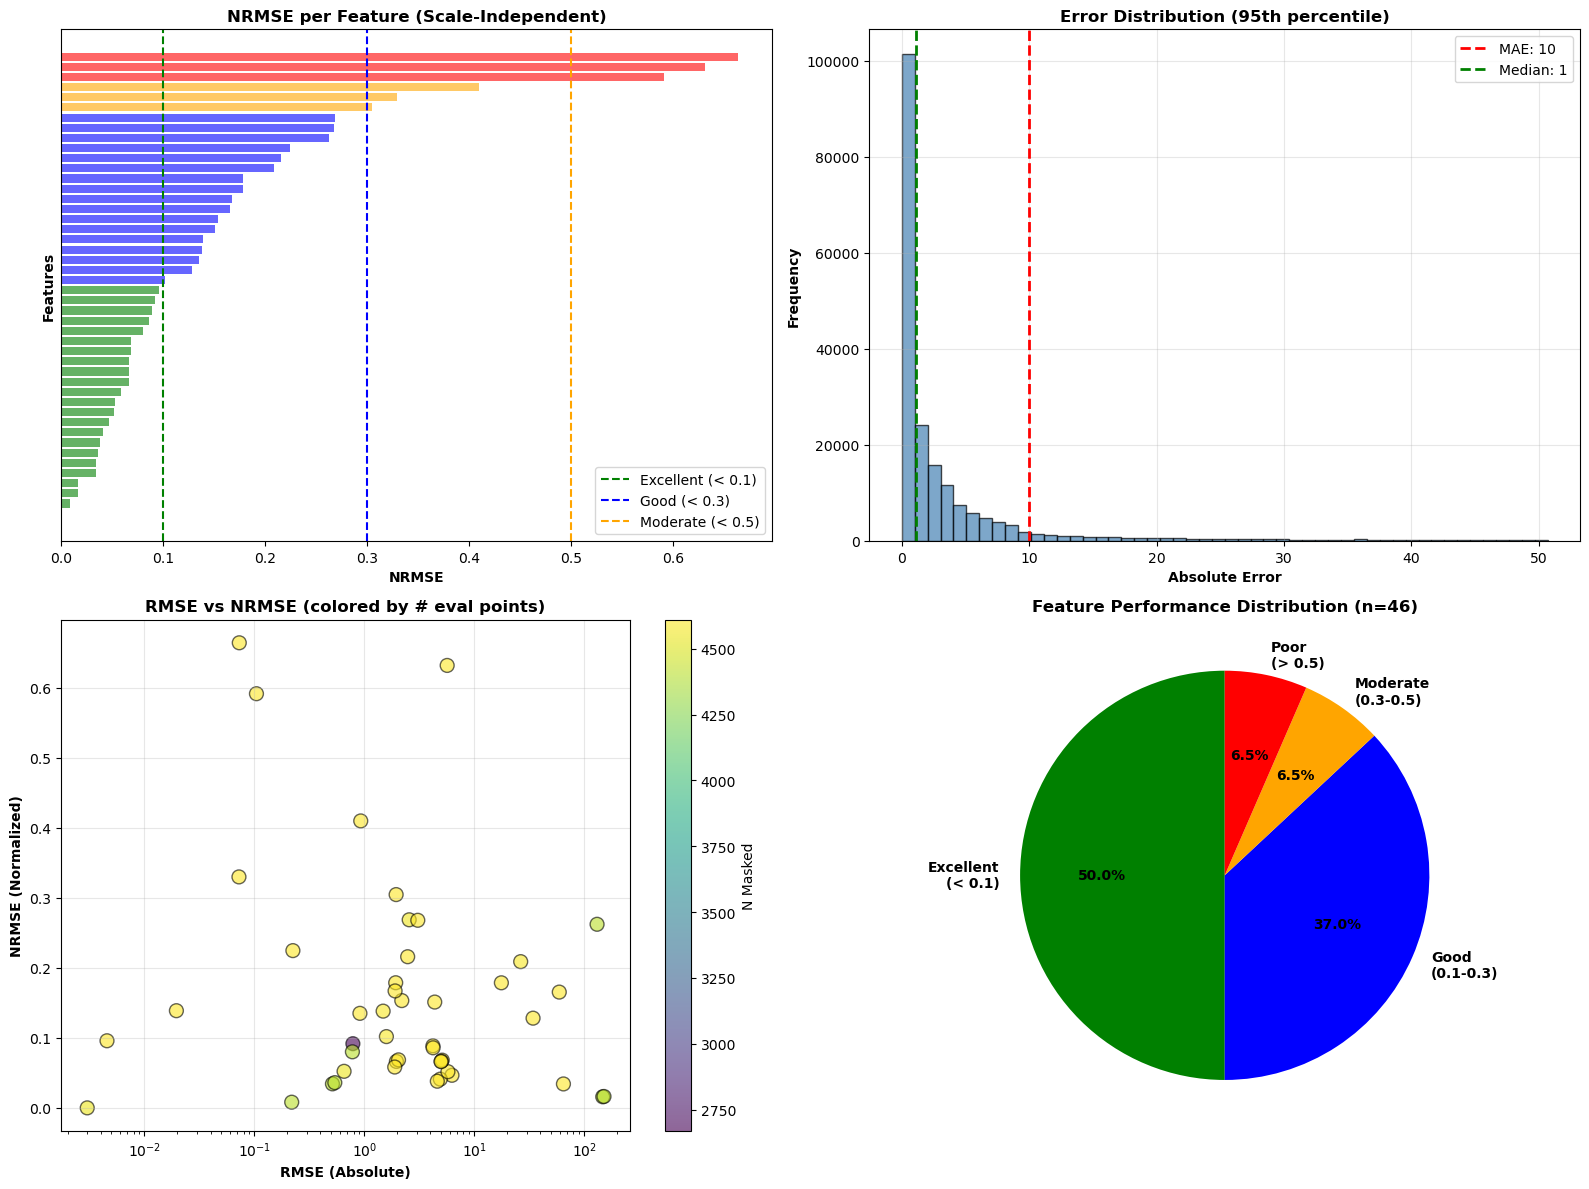

In [23]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: NRMSE distribution
ax1 = axes[0, 0]
results_sorted = results_df.sort_values('NRMSE')
colors = ['green' if x < 0.1 else 'blue' if x < 0.3 else 'orange' if x < 0.5 else 'red' 
          for x in results_sorted['NRMSE']]
ax1.barh(range(len(results_sorted)), results_sorted['NRMSE'], color=colors, alpha=0.6)
ax1.axvline(x=0.1, color='green', linestyle='--', label='Excellent (< 0.1)')
ax1.axvline(x=0.3, color='blue', linestyle='--', label='Good (< 0.3)')
ax1.axvline(x=0.5, color='orange', linestyle='--', label='Moderate (< 0.5)')
ax1.set_xlabel('NRMSE', fontweight='bold')
ax1.set_ylabel('Features', fontweight='bold')
ax1.set_title('NRMSE per Feature (Scale-Independent)', fontweight='bold', fontsize=12)
ax1.legend()
ax1.set_yticks([])

# Plot 2: Error distribution
ax2 = axes[0, 1]
errors_abs_array = np.array(all_errors_abs)
ax2.hist(errors_abs_array[errors_abs_array < np.percentile(errors_abs_array, 95)], 
         bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=overall_mae, color='red', linestyle='--', linewidth=2, label=f'MAE: {overall_mae:,.0f}')
ax2.axvline(x=overall_median_ae, color='green', linestyle='--', linewidth=2, label=f'Median: {overall_median_ae:,.0f}')
ax2.set_xlabel('Absolute Error', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.set_title('Error Distribution (95th percentile)', fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: RMSE vs NRMSE
ax3 = axes[1, 0]
scatter = ax3.scatter(results_df['RMSE'], results_df['NRMSE'], 
                     c=results_df['n_masked'], cmap='viridis', 
                     alpha=0.6, s=100, edgecolors='black')
ax3.set_xlabel('RMSE (Absolute)', fontweight='bold')
ax3.set_ylabel('NRMSE (Normalized)', fontweight='bold')
ax3.set_title('RMSE vs NRMSE (colored by # eval points)', fontweight='bold', fontsize=12)
ax3.set_xscale('log')
plt.colorbar(scatter, ax=ax3, label='N Masked')
ax3.grid(alpha=0.3)

# Plot 4: Feature categories pie chart
ax4 = axes[1, 1]
categories = ['Excellent\n(< 0.1)', 'Good\n(0.1-0.3)', 'Moderate\n(0.3-0.5)', 'Poor\n(> 0.5)']
sizes = [len(excellent), len(good), len(moderate), len(poor)]
colors_pie = ['green', 'blue', 'orange', 'red']
ax4.pie(sizes, labels=categories, colors=colors_pie, autopct='%1.1f%%',
        startangle=90, textprops={'fontweight': 'bold'})
ax4.set_title(f'Feature Performance Distribution (n={len(results)})', 
             fontweight='bold', fontsize=12)

plt.tight_layout()

plt.show()



In [25]:
import os
os.makedirs('research/models', exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'clipping_bounds': clipping_bounds,
    'history': history,
    'hyperparameters': {
        'input_dim': INPUT_DIM,
        'hidden_dims': HIDDEN_DIMS,
        'batch_size': BATCH_SIZE,
        'noise_ratio': NOISE_RATIO,
        'best_val_loss': best_val_loss
    },
    'features': continuous_features
}, 'research/models/simple_dae_model.pt')

print("✓ Saved: models/simple_dae_model.pt")

# Save history
history_df = pd.DataFrame({
    'epoch': range(1, len(history['train_loss']) + 1),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'epoch_time': history['epoch_times']
})
history_df.to_csv('research/models/simple_dae_history.csv', index=False)
print(" Saved: models/simple_dae_history.csv")


✓ Saved: models/simple_dae_model.pt
 Saved: models/simple_dae_history.csv
